<a href="https://colab.research.google.com/github/edi-oliveira1979/RAG-RAT-com-DeepEval-e-Langfuse/blob/main/notebook_pln_rag_medico_portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retrieval-Augmented Generation for Medical Question Answering  
## Comparison of RAG, RAG + Chain-of-Thought and RAT

### Abstract

Retrieval-Augmented Generation (RAG) has emerged as a promising paradigm for improving factual grounding in large language model (LLM) outputs. In domains such as biomedical question answering, grounding model responses in scientific evidence is particularly important.

This notebook presents an experimental comparison of three context-conditioned generation strategies applied to the **PubMedQA** dataset:

- RAG
- RAG with Chain-of-Thought reasoning
- RAT (Retrieval-Augmented Thought)

The experiment evaluates how these approaches behave in a **three-class medical QA task** (`yes`, `no`, `maybe`). In addition to label accuracy, the study analyzes retrieval performance, faithfulness to evidence, and system robustness under variations in context size and sampling temperature.

Results show that while all strategies achieve similar label accuracy, they differ in robustness and faithfulness. In particular, RAT demonstrates more stable behavior in ambiguous cases and stronger adherence to retrieved evidence.

---

### Keywords

Retrieval-Augmented Generation, Medical Question Answering, PubMedQA, Large Language Models, Evidence Grounding, NLP

## Experiment Overview

This notebook implements and evaluates a **Retrieval-Augmented Generation (RAG) pipeline** for biomedical question answering.

The main goal is to compare three strategies for generating answers conditioned on retrieved scientific evidence:

| Strategy | Description |
|--------|-------------|
| **RAG** | Direct answer generation using retrieved context |
| **RAG + CoT** | Generation with explicit intermediate reasoning |
| **RAT** | Evidence-oriented structured generation |

The study investigates three main questions:

1. How do these strategies perform in a **three-class medical QA task**?
2. Does **explicit reasoning (Chain-of-Thought)** improve decision quality?
3. How robust are the strategies to changes in **context size and generation temperature**?

The experiment combines:

- **dense retrieval (FAISS + embeddings)**
- **LLM-based generation**
- **LLM-as-Judge evaluation**

## System Pipeline

The experimental pipeline follows a standard **retrieval-augmented architecture**:

1. Medical abstracts are segmented into chunks.
2. Dense embeddings are generated for each chunk.
3. A FAISS vector index is constructed.
4. For each question:
   - relevant chunks are retrieved
   - context is assembled
   - the LLM generates an answer
5. Predictions are evaluated against the gold label.

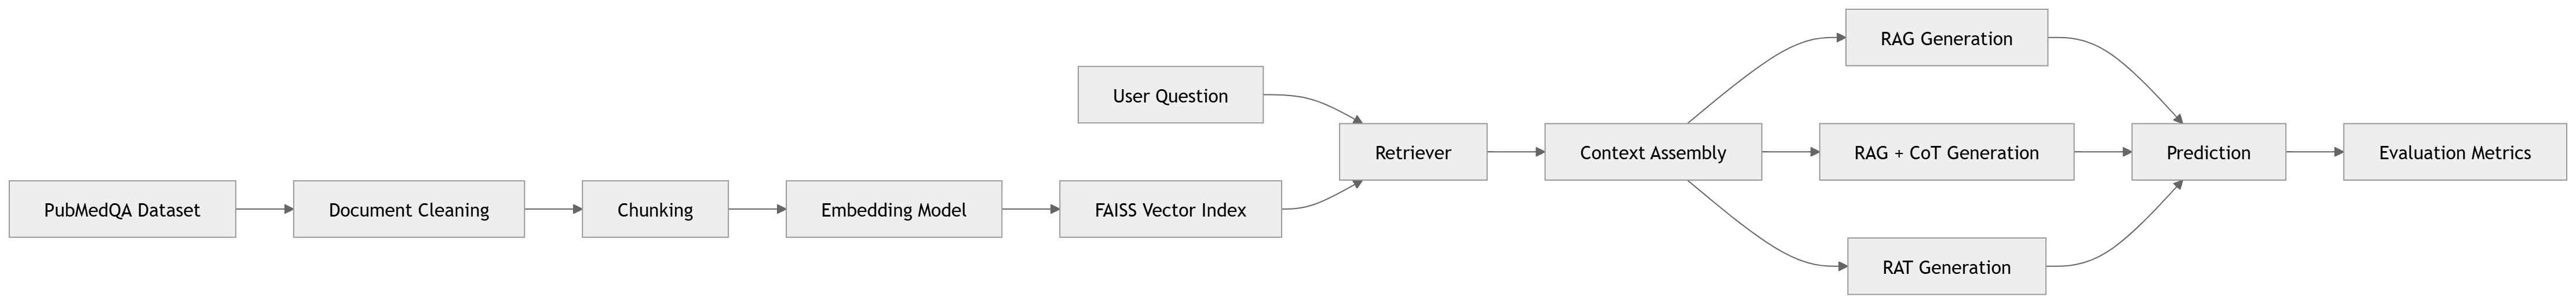

## Dataset

The experiments use the **PubMedQA** dataset, specifically the `pqa_labeled` subset.

This dataset contains biomedical questions associated with scientific abstracts and expert annotations.

After preprocessing, the dataset used in the experiments contains **410 instances** with the following label distribution:

| Label | Count |
|------|------|
| yes | 150 |
| no | 150 |
| maybe | 110 |

Each instance includes:

- `question`
- `context` (abstract)
- `long_answer`
- `final_decision`

The `final_decision` field was normalized into the variable **gold_label** used in evaluation.

The contexts correspond to **scientific abstracts**, with average length around **1300 characters**.

## Retrieval Pipeline

The retrieval stage is implemented using **dense vector search**.

Main components:

| Component | Configuration |
|-----------|--------------|
| Embedding model | `BAAI/bge-small-en-v1.5` |
| Vector index | FAISS |
| Chunk size | 1200 characters |
| Chunk overlap | 180 characters |
| Retriever type | bi-encoder dense retrieval |

Documents are segmented into chunks using `RecursiveCharacterTextSplitter`.

During retrieval:

- similarity search is performed over the chunk index
- retrieved chunks are grouped by **parent document**
- context is assembled from the top-ranked documents

In the main experiments:

- **top-k = 5** documents for RAG and RAG+CoT
- **top-k = 3** effective documents for RAT

## Generation Strategies

All strategies use the same base LLM:

**Model:** `gemini-3.1-flash-lite-preview`

Default parameters:

| Parameter | Value |
|-----------|------|
| Temperature | 0.0 |
| Max tokens | 300 |

---

### RAG

Generates the answer directly based on retrieved context.

Output includes:

- predicted label
- answer
- justification

---

### RAG + Chain-of-Thought

The prompt encourages the model to produce **intermediate reasoning** before the final decision.

Output includes:

- reasoning
- predicted label
- answer
- justification

---

### RAT

The RAT approach enforces **explicit grounding in retrieved evidence**.

Output includes:

- predicted label
- answer
- justification
- evidence used

## Evaluation Methodology

Two evaluation sets were constructed.

### Generation evaluation

- 9 examples
- balanced across the three labels

### Retrieval evaluation

- 90 examples
- 30 per label

Metrics include:

| Metric | Description |
|------|-------------|
| Accuracy | label prediction accuracy |
| Macro-F1 | class-balanced performance |
| Latency | average generation time |

Additionally, **LLM-as-Judge evaluation** was applied.

Two dimensions were assessed:

**Correctness**

Consistency between generated answer and reference explanation.

**Faithfulness**

Degree to which the answer is supported by retrieved evidence.

## Main Results

All strategies achieved the same **label accuracy (0.7778)** in the generation experiment.

| Strategy | Accuracy | Macro-F1 | Correctness | Faithfulness | Latency |
|--------|--------|--------|--------|--------|--------|
| RAG | 0.7778 | 0.7381 | 0.8333 | 0.9444 | 4.48 s |
| RAG + CoT | 0.7778 | 0.7500 | 0.7778 | 0.9444 | 1.26 s |
| RAT | 0.7778 | 0.7778 | 0.8333 | 1.0000 | 1.04 s |

Key observations:

- performance differences are mostly visible in **secondary metrics**
- most errors occur in the **maybe** class
- RAT shows the **highest faithfulness and stability**

## Diagnostic Experiments

### Retrieval performance

The retriever achieved near-perfect performance:

- HR@1 = 0.9889
- HR@3 = 0.9889
- HR@5 = 0.9889
- MRR@10 = 0.9889

This indicates that **retrieval is not the main bottleneck** in the system.

---

### Context size experiment

Three context configurations were tested:

- short context
- medium context
- full context

The main variation occurs in the **maybe** class.

RAT maintained stable predictions across all configurations.

---

### Temperature experiment

Temperatures tested:

- 0.0
- 0.2
- 0.5

Predictions remained largely unchanged, indicating that the system behavior is primarily determined by **prompt structure and evidence**, rather than sampling variability.

## Conclusion

The experiments show that the three strategies reach similar label accuracy, but differ in qualitative behavior.

Key findings:

- retrieval performance is extremely strong and not the primary bottleneck
- the most difficult cases correspond to the **maybe** class
- Chain-of-Thought reasoning does not significantly improve performance in this setup
- the RAT approach shows **more stable behavior and stronger evidence grounding**

These results suggest that, in medical QA settings with strong retrieval, system performance depends more on **how evidence is structured and enforced in generation** than on simply expanding context or encouraging longer reasoning traces.

## Início do Pipeline

# [M00] Projeto PLN — RAG Médico com comparação entre **RAG**, **RAG+CoT** e **RAT**
**Notebook ajustado para Google Colab**

## Objetivo deste notebook
Este notebook foi organizado para atender aos requisitos mínimos da disciplina e, ao mesmo tempo, realizar a comparação entre três estratégias de geração:

1. **RAG básico**
2. **RAG + CoT**
3. **RAT (Retrieval-Augmented Thoughts)**

## Requisitos atendidos
- **Obter dados de perguntas/respostas** → Fases [M03] e [C03]
- **Implementar indexação dos documentos** → Fases [M05], [C06] e [C07]
- **Implementar retriever** → Fases [M06] e [C08]
- **Implementar gerador de resposta** → Fases [M07], [C10], [C11] e [C12]
- **Avaliar qualidade dos resultados com métricas baseadas em LLMs** → Fases [M09], [C15] e [C16]
- **Métricas de recuperação de informação (bônus)** → Fases [M06] e [C09]


# [M01] Decisão sobre o dataset:
## Como o dataset será usado neste notebook
- **`context`** → usado como **corpus** indexado no retriever
- **`question`** → usada como **consulta**
- **`final_decision`** → usado como **rótulo principal de avaliação** (`yes`, `no`, `maybe`)
- **`long_answer`** → usada como **referência textual** para ajudar a avaliar correctness

## Por que isso é suficiente
Esse dataset já permite cumprir o fluxo completo solicitado:
**dados → indexação → retrieval → geração → avaliação**.

## Limitação importante
Como a pergunta e o contexto vêm da mesma base, a tarefa de recuperação tende a ser **mais favorável** do que num cenário totalmente aberto.


# [M02] Instruções de uso no Colab

## Antes de rodar
1. Abra este notebook no **Google Colab**
2. Ative, se possível, **GPU** em `Ambiente de execução > Alterar tipo de ambiente de execução`
3. Cadastre a chave `GEMINI_API_KEY` em:
   - menu lateral do Colab
   - ícone de chave/segredos
   - nome do segredo: `GEMINI_API_KEY`

## Tempo esperado
- **FAST_MODE = True**: execução mais rápida, boa para a entrega
- **FAST_MODE = False**: execução mais completa, boa para refinamento posterior

## Observação didática
As células foram divididas em fases bem identificadas para facilitar:
- leitura
- referência futura no relatório
- reaproveitamento em um possível artigo exploratório


In [ ]:
# ============================================================
# [C01] Instalação do ambiente
# ============================================================

!pip uninstall -y google-generativeai google-ai-generativelanguage langgraph-prebuilt langgraph || true

!pip install -q -U \
  requests==2.32.4 \
  datasets \
  faiss-cpu \
  sentence-transformers \
  transformers \
  langchain \
  langchain-core \
  langchain-community \
  langchain-text-splitters \
  langchain-huggingface \
  langchain-google-genai \
  google-genai \
  deepeval

In [ ]:
# [C02] Imports, configuração global e carregamento da API key

import os
import re
import json
import math
import time
import shutil
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from tqdm.auto import tqdm
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, f1_score

import nest_asyncio
nest_asyncio.apply()

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_google_genai import ChatGoogleGenerativeAI

warnings.filterwarnings("ignore")

# ----------------------------
# Configuração principal
# ----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

FAST_MODE = True              # True = mais rápido para entrega; False = mais completo
FORCE_REINDEX = False         # True = recria o índice do zero
CORPUS_LIMIT = 450 if FAST_MODE else None

# Amostra pequena para geração + avaliação com LLM
EVAL_PER_LABEL = 3 if FAST_MODE else 5

# Amostra ampliada APENAS para retrieval
RETRIEVAL_EVAL_PER_LABEL = 30 if FAST_MODE else 60

TOP_K_BASE = 10
TOP_K_RAT_PER_NEED = 5
TOP_K_RAT = TOP_K_RAT_PER_NEED   # alias para compatibilidade

DATASET_NAME = "pubmed_qa"
DATASET_SUBSET = "pqa_labeled"

EMBED_MODEL = "BAAI/bge-small-en-v1.5"
GEMINI_MODEL = "gemini-3.1-flash-lite-preview"   # ajuste se sua conta exigir outro alias

WORKDIR = Path("/content/pln_rag_medico")
INDEX_DIR = WORKDIR / "faiss_index"
OUTPUT_DIR = WORKDIR / "outputs"
WORKDIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Ambiente configurado.")
print(f"FAST_MODE={FAST_MODE}")
print(f"CORPUS_LIMIT={CORPUS_LIMIT}")
print(f"EVAL_PER_LABEL={EVAL_PER_LABEL} (geração/juiz)")
print(f"RETRIEVAL_EVAL_PER_LABEL={RETRIEVAL_EVAL_PER_LABEL} (somente retrieval)")
print(f"TOP_K_BASE={TOP_K_BASE}")
print(f"TOP_K_RAT={TOP_K_RAT}")

# ----------------------------
# API key do Gemini
# ----------------------------
GEMINI_API_KEY = None

try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError(
        "GEMINI_API_KEY não encontrada. Cadastre a chave nos Secrets do Colab "
        "ou defina a variável de ambiente GEMINI_API_KEY."
    )

os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

print("✅ Ambiente configurado.")
print(f"FAST_MODE={FAST_MODE} | CORPUS_LIMIT={CORPUS_LIMIT} | EVAL_PER_LABEL={EVAL_PER_LABEL}")


# [M03] Carregamento e inspeção do dataset

Nesta etapa:
1. carrega-se o dataset do Hugging Face
2. inspeciona-se as colunas
3. prepara-se a base para o pipeline

A ideia aqui é deixar **explícito** como cada campo do dataset será aproveitado.


In [ ]:
# [C03] Carga do dataset e inspeção inicial

dataset = load_dataset(DATASET_NAME, DATASET_SUBSET, split="train")
df_raw = pd.DataFrame(dataset)

print(f"Total de registros carregados: {len(df_raw)}")
print("\nColunas disponíveis:")
print(df_raw.columns.tolist())

print("\nExemplo da primeira linha (campos resumidos):")
for col in df_raw.columns:
    value = df_raw.iloc[0][col]
    print(f"- {col}: {str(value)[:160]}")


In [ ]:
# [C04] Pré-processamento e padronização do dataset

def extract_context_text(context_obj):
    """Consolida o texto do campo context em uma única string."""
    if isinstance(context_obj, dict):
        parts = context_obj.get("contexts", [])
        if isinstance(parts, list):
            return " ".join([str(x).strip() for x in parts if str(x).strip()])
    return ""

df = df_raw.copy()

df["context_text"] = df["context"].apply(extract_context_text)
df["reference_answer"] = df["long_answer"].fillna("").astype(str).str.strip()
df["gold_label"] = df["final_decision"].fillna("").astype(str).str.strip().str.lower()
df["doc_id"] = np.arange(len(df))

# Mantemos apenas os registros úteis
df = df[
    (df["question"].notna()) &
    (df["context_text"].str.len() > 0) &
    (df["gold_label"].isin(["yes", "no", "maybe"]))
].copy()

# Métricas simples de tamanho
df["context_chars"] = df["context_text"].str.len()
df["context_words"] = df["context_text"].str.split().str.len()

# Opcional: reduzir corpus para acelerar a entrega, mantendo estratificação por rótulo
if CORPUS_LIMIT is not None and CORPUS_LIMIT < len(df):
    parts = []
    labels = sorted(df["gold_label"].unique())
    per_label = CORPUS_LIMIT // len(labels)
    for label in labels:
        part = df[df["gold_label"] == label].sample(
            n=min(per_label, (df["gold_label"] == label).sum()),
            random_state=SEED
        )
        parts.append(part)
    df = pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
    df["doc_id"] = np.arange(len(df))

print(f"Total após limpeza/amostragem: {len(df)}")
print("\nDistribuição de rótulos:")
print(df["gold_label"].value_counts())

display(df[["doc_id", "question", "gold_label", "reference_answer"]].head(3))

# Persistência para inspeção posterior
df.to_csv(OUTPUT_DIR / "dataset_processado.csv", index=False)


In [ ]:
# [C05] EDA rápida para justificar chunking e tamanho do experimento

summary = df[["context_chars", "context_words"]].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).T
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["context_chars"], bins=30)
axes[0].set_title("Distribuição de caracteres por contexto")
axes[0].set_xlabel("Caracteres")
axes[0].set_ylabel("Frequência")

axes[1].hist(df["context_words"], bins=30)
axes[1].set_title("Distribuição de palavras por contexto")
axes[1].set_xlabel("Palavras")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

# Estratégia de chunking:
# Como os abstracts costumam ser relativamente curtos, a divisão pode ser conservadora.
# Usamos um valor guiado pela distribuição, mas com limites razoáveis.
chunk_size = int(np.clip(df["context_chars"].quantile(0.75), 700, 1200))
chunk_overlap = int(chunk_size * 0.15)

print(f"chunk_size sugerido = {chunk_size}")
print(f"chunk_overlap sugerido = {chunk_overlap}")


# [M04] Definição do conjunto de avaliação

Para otimizar o experimento, o conjunto de avaliação será:
- **estratificado por rótulo**
- **fixo e reproduzível**
- relativamente pequeno

Isso facilita comparar as três estratégias no mesmo cenário.


In [ ]:
# ============================================================
# [C06] Criação dos conjuntos de avaliação
# - eval_df: geração + LLM-as-Judge
# - retrieval_eval_df: somente métricas de retrieval
# ============================================================

def stratified_sample(df_in, label_col, n_per_label, seed=42):
    """
    Cria uma amostra estratificada e reprodutível por classe.

    Parâmetros:
      - df_in: dataframe de entrada
      - label_col: nome da coluna de rótulo
      - n_per_label: número desejado de exemplos por classe
      - seed: semente para reprodutibilidade

    Retorna:
      - dataframe amostrado de forma estratificada
    """
    sampled_parts = []

    for label in sorted(df_in[label_col].dropna().unique()):
        subset = df_in[df_in[label_col] == label].copy()
        n_take = min(n_per_label, len(subset))

        sampled_subset = subset.sample(
            n=n_take,
            random_state=seed
        )

        sampled_parts.append(sampled_subset)

    sampled_df = (
        pd.concat(sampled_parts, axis=0)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )

    return sampled_df


# ------------------------------------------------------------
# 1) Conjunto para geração + LLM-as-Judge
# ------------------------------------------------------------
eval_df = stratified_sample(
    df_in=df,
    label_col="gold_label",
    n_per_label=EVAL_PER_LABEL,
    seed=SEED
)

# ------------------------------------------------------------
# 2) Conjunto ampliado APENAS para retrieval
# ------------------------------------------------------------
retrieval_eval_df = stratified_sample(
    df_in=df,
    label_col="gold_label",
    n_per_label=RETRIEVAL_EVAL_PER_LABEL,
    seed=SEED + 1
)

# ------------------------------------------------------------
# Exibição dos resultados
# ------------------------------------------------------------
print("✅ Conjuntos de avaliação criados.\n")

print("Conjunto para geração + LLM-as-Judge")
print(f"Tamanho: {len(eval_df)}")
print(eval_df["gold_label"].value_counts().sort_index())

print("\nConjunto ampliado para retrieval")
print(f"Tamanho: {len(retrieval_eval_df)}")
print(retrieval_eval_df["gold_label"].value_counts().sort_index())

print("\nAmostra de eval_df:")
display(eval_df[["doc_id", "question", "gold_label"]].head(10))

print("\nAmostra de retrieval_eval_df:")
display(retrieval_eval_df[["doc_id", "question", "gold_label"]].head(10))

# ------------------------------------------------------------
# Salvando os dois conjuntos
# ------------------------------------------------------------
eval_df.to_csv(OUTPUT_DIR / "eval_set_generation.csv", index=False)
retrieval_eval_df.to_csv(OUTPUT_DIR / "eval_set_retrieval.csv", index=False)

print(f"\nArquivo salvo: {OUTPUT_DIR / 'eval_set_generation.csv'}")
print(f"Arquivo salvo: {OUTPUT_DIR / 'eval_set_retrieval.csv'}")


# [M05] Indexação do corpus

Nesta fase:
1. transforma-se cada abstract em chunks
2. preserva-se o `doc_id` do documento de origem
3. cria-se um índice vetorial com embeddings

Essa separação entre **documento pai** e **chunk** é importante porque:
- a recuperação acontece em nível de chunk
- a avaliação de recuperação pode ser feita em nível de documento pai

## Observação técnica
Nesta versão usa-se **FAISS** em vez de **Chroma**, dado que, para Colab, FAISS tende a ser mais estável e mais leve, além de evitar conflitos de dependências.


In [ ]:
# [C07] Criação dos chunks e indexação no FAISS

splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    separators=["\n\n", "\n", ". ", " "]
)

langchain_docs = []
for row in df.itertuples(index=False):
    chunks = splitter.split_text(row.context_text)
    for i, chunk in enumerate(chunks):
        langchain_docs.append(
            Document(
                page_content=chunk,
                metadata={
                    "parent_doc_id": int(row.doc_id),
                    "pubid": str(row.pubid),
                    "gold_label": str(row.gold_label),
                    "chunk_id": int(i)
                }
            )
        )

print(f"Total de chunks gerados: {len(langchain_docs)}")

# Embeddings locais
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True}
)

# Verificação do índice salvo localmente.
# O FAISS salva dois artefatos principais no diretório:
# - index.faiss
# - index.pkl
faiss_file = INDEX_DIR / "index.faiss"
pkl_file = INDEX_DIR / "index.pkl"

index_exists = faiss_file.exists() and pkl_file.exists()
needs_indexing = FORCE_REINDEX or (not index_exists)

if FORCE_REINDEX and INDEX_DIR.exists():
    shutil.rmtree(INDEX_DIR)
    needs_indexing = True

if needs_indexing:
    print("⏳ Indexando documentos com FAISS...")
    vectorstore = FAISS.from_documents(
        documents=langchain_docs,
        embedding=embedding_model
    )
    INDEX_DIR.mkdir(parents=True, exist_ok=True)
    vectorstore.save_local(str(INDEX_DIR))
    print("✅ Indexação concluída e salva localmente.")
else:
    vectorstore = FAISS.load_local(
        str(INDEX_DIR),
        embedding_model,
        allow_dangerous_deserialization=True
    )
    print("✅ Índice FAISS reaproveitado do diretório persistente.")

retriever = vectorstore.as_retriever(search_kwargs={"k": TOP_K_BASE})


# [M06] Retriever e métricas de recuperação (bônus)

Aqui mede-se se o retriever encontra o documento de origem da pergunta.
Como o conjunto de avaliação foi derivado do mesmo corpus, a métrica tende a ser otimista, mas ainda é útil para separar:
- problema de recuperação
- problema de geração


In [ ]:
# [C08] Funções auxiliares do retriever

def retrieve_chunks(question, k=TOP_K_BASE):
    """Retorna lista de pares (Document, score), com score maior = melhor.

    No FAISS, o método padrão retorna distância (quanto menor, melhor).
    Para facilitar a leitura e o ranqueamento ao longo do notebook,
    convertemos a distância para uma pseudo-similaridade monotônica:
        score = 1 / (1 + distance)
    Isso não muda a ordem dos resultados; só deixa a interpretação mais intuitiva.
    """
    docs_and_distances = vectorstore.similarity_search_with_score(question, k=k)
    docs_and_scores = []
    for doc, distance in docs_and_distances:
        distance = float(distance)
        score = 1.0 / (1.0 + max(distance, 0.0))
        docs_and_scores.append((doc, score))
    return docs_and_scores

def collapse_to_parent_docs(docs_and_scores):
    """Agrupa chunks por documento pai, mantendo o melhor score por documento."""
    grouped = {}
    for doc, score in docs_and_scores:
        parent_id = int(doc.metadata["parent_doc_id"])
        if parent_id not in grouped:
            grouped[parent_id] = {
                "score": float(score),
                "chunks": [doc.page_content],
                "metadatas": [doc.metadata]
            }
        else:
            grouped[parent_id]["score"] = max(grouped[parent_id]["score"], float(score))
            if doc.page_content not in grouped[parent_id]["chunks"]:
                grouped[parent_id]["chunks"].append(doc.page_content)
                grouped[parent_id]["metadatas"].append(doc.metadata)

    ranked = sorted(grouped.items(), key=lambda x: x[1]["score"], reverse=True)
    return ranked

def format_context_from_ranked(ranked_docs, max_docs=TOP_K_BASE):
    blocks = []
    for rank, (parent_id, payload) in enumerate(ranked_docs[:max_docs], start=1):
        merged_text = "\n".join(payload["chunks"][:2])
        blocks.append(
            f"[DOC {rank} | parent_doc_id={parent_id} | score={payload['score']:.4f}]\n{merged_text}"
        )
    return "\n\n".join(blocks)

# Demonstração rápida
demo_question = eval_df.iloc[0]["question"]
demo_retrieved = retrieve_chunks(demo_question, k=TOP_K_BASE)
demo_ranked = collapse_to_parent_docs(demo_retrieved)

print("Pergunta de demonstração:")
print(demo_question)
print("\nDocumentos pai recuperados:")
for rank, (pid, payload) in enumerate(demo_ranked, start=1):
    print(f"{rank}. parent_doc_id={pid} | best_score={payload['score']:.4f}")


In [ ]:
# ============================================================
# [C09] Métricas de recuperação: Hit Rate@K e MRR
# Usa retrieval_eval_df (amostra ampliada somente para retrieval)
# ============================================================

def rank_of_gold_doc(question, gold_doc_id, k=10):
    """
    Retorna a posição (rank) do documento correto no ranking recuperado.

    Se o documento correto estiver em 1º lugar, retorna 1.
    Se estiver em 2º lugar, retorna 2.
    Se não estiver entre os k recuperados, retorna None.
    """
    docs_scores = retrieve_chunks(question, k=k)
    ranked = collapse_to_parent_docs(docs_scores)
    ranked_ids = [int(pid) for pid, _ in ranked]

    if int(gold_doc_id) in ranked_ids:
        return ranked_ids.index(int(gold_doc_id)) + 1

    return None


def hit_rate_at_k(eval_frame, k=1, retrieval_k=10):
    """
    Calcula Hit Rate@K:
    proporção de exemplos em que o documento correto aparece entre os top-k.
    """
    hits = 0

    for row in eval_frame.itertuples(index=False):
        rank = rank_of_gold_doc(
            question=row.question,
            gold_doc_id=int(row.doc_id),
            k=max(k, retrieval_k)
        )

        if rank is not None and rank <= k:
            hits += 1

    return hits / len(eval_frame) if len(eval_frame) > 0 else 0.0


def mean_reciprocal_rank(eval_frame, k=10):
    """
    Calcula MRR@K:
    média do inverso da posição do primeiro documento correto recuperado.
    """
    rr = []

    for row in eval_frame.itertuples(index=False):
        rank = rank_of_gold_doc(
            question=row.question,
            gold_doc_id=int(row.doc_id),
            k=k
        )

        rr.append(0.0 if rank is None else 1.0 / rank)

    return float(np.mean(rr)) if len(rr) > 0 else 0.0


def build_retrieval_detailed_df(eval_frame, retrieval_k=10):
    """
    Gera um dataframe detalhado por pergunta para auditoria do retriever.
    """
    rows = []

    for row in tqdm(list(eval_frame.itertuples(index=False)), desc="Retrieval evaluation"):
        question = row.question
        gold_doc_id = int(row.doc_id)
        gold_label = row.gold_label

        docs_scores = retrieve_chunks(question, k=retrieval_k)
        ranked = collapse_to_parent_docs(docs_scores)
        ranked_ids = [int(pid) for pid, _ in ranked]

        rank = None
        if gold_doc_id in ranked_ids:
            rank = ranked_ids.index(gold_doc_id) + 1

        rows.append({
            "doc_id": gold_doc_id,
            "gold_label": gold_label,
            "question": question,
            "retrieved_parent_ids": ranked_ids,
            "rank_of_gold_doc": rank,
            "hit@1": int(rank is not None and rank <= 1),
            "hit@3": int(rank is not None and rank <= 3),
            "hit@5": int(rank is not None and rank <= 5),
            "rr@10": 0.0 if rank is None else 1.0 / rank
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Construção do dataframe detalhado de retrieval
# ------------------------------------------------------------
retrieval_metrics_df = build_retrieval_detailed_df(
    retrieval_eval_df,
    retrieval_k=10
)

# ------------------------------------------------------------
# Métricas agregadas
# ------------------------------------------------------------
ir_metrics = {
    "n_examples": len(retrieval_metrics_df),
    "HR@1": retrieval_metrics_df["hit@1"].mean(),
    "HR@3": retrieval_metrics_df["hit@3"].mean(),
    "HR@5": retrieval_metrics_df["hit@5"].mean(),
    "MRR@10": retrieval_metrics_df["rr@10"].mean(),
}

ir_df = pd.DataFrame([ir_metrics])

print("✅ Métricas de recuperação calculadas sobre retrieval_eval_df")
display(ir_df)

print("\nAmostra detalhada da auditoria de retrieval:")
display(
    retrieval_metrics_df[
        ["doc_id", "gold_label", "rank_of_gold_doc", "hit@1", "hit@3", "hit@5", "rr@10"]
    ].head(10)
)

# ------------------------------------------------------------
# Salvando resultados
# ------------------------------------------------------------
ir_df.to_csv(OUTPUT_DIR / "ir_metrics_summary.csv", index=False)
retrieval_metrics_df.to_csv(OUTPUT_DIR / "ir_metrics_detailed.csv", index=False)

print(f"\nResumo salvo em:   {OUTPUT_DIR / 'ir_metrics_summary.csv'}")
print(f"Detalhes salvos em: {OUTPUT_DIR / 'ir_metrics_detailed.csv'}")


In [ ]:
# ============================================================
# [C09.1] Métricas de retrieval por classe
# ============================================================

# Verificação básica
required_cols = ["gold_label", "hit@1", "hit@3", "hit@5", "rr@10"]
missing_cols = [col for col in required_cols if col not in retrieval_metrics_df.columns]

if missing_cols:
    raise ValueError(
        f"As colunas abaixo não foram encontradas em retrieval_metrics_df: {missing_cols}\n"
        "Verifique se a C09 foi executada corretamente antes da C09.1."
    )

# Agregação por classe
ir_by_label_df = (
    retrieval_metrics_df
    .groupby("gold_label", as_index=False)
    .agg(
        n_examples=("doc_id", "count"),
        HR_at_1=("hit@1", "mean"),
        HR_at_3=("hit@3", "mean"),
        HR_at_5=("hit@5", "mean"),
        MRR_at_10=("rr@10", "mean")
    )
    .sort_values("gold_label")
    .reset_index(drop=True)
)

print("✅ Métricas de retrieval por classe")
display(ir_by_label_df)

# Salvando para análise posterior
ir_by_label_df.to_csv(OUTPUT_DIR / "ir_metrics_by_label.csv", index=False)
print(f"Arquivo salvo em: {OUTPUT_DIR / 'ir_metrics_by_label.csv'}")

In [ ]:
# C09.2 - Casos em que o documento correto não foi encontrado no top-10
retrieval_failures_df = retrieval_metrics_df[retrieval_metrics_df["rank_of_gold_doc"].isna()].copy()

print(f"Número de falhas de retrieval: {len(retrieval_failures_df)}")
display(retrieval_failures_df[["doc_id", "gold_label", "question", "retrieved_parent_ids"]])

In [ ]:
# C09.3 - Inspecionar o caso de falha de retrieval

failure_row = df[df["doc_id"] == 91].iloc[0]

print("DOC_ID correto:", failure_row["doc_id"])
print("Rótulo:", failure_row["gold_label"])
print("\nPergunta:")
print(failure_row["question"])

print("\nResposta de referência:")
print(failure_row["reference_answer"][:1000])

print("\nContexto do documento correto:")
print(str(failure_row["context"])[:2000])

In [ ]:
retrieved_ids = [207, 80, 298, 373, 63, 235, 273]

for rid in retrieved_ids[:3]:
    row = df[df["doc_id"] == rid].iloc[0]
    print("=" * 80)
    print("DOC_ID recuperado:", rid)
    print("Rótulo:", row["gold_label"])
    print("Pergunta:")
    print(row["question"])
    print("\nContexto:")
    print(str(row["context"])[:1200])
    print()

# [M07] Definição do LLM e das três estratégias de geração

Todas as estratégias produzem a **mesma estrutura de saída**:

```json
{
  "predicted_label": "yes | no | maybe",
  "answer": "...",
  "justification": "..."
}
```

Isso é importante para permitir uma comparação justa.

## Estratégias
### 1. RAG básico
Recupera contexto uma vez e responde diretamente.

### 2. RAG + CoT
Usa o mesmo contexto, mas pede um raciocínio clínico mais estruturado antes da conclusão.

### 3. RAT
Primeiro decompõe a pergunta em pequenas necessidades de evidência.
Depois recupera evidências para cada necessidade e só então responde.


In [ ]:
# ============================================================
# [C10] Inicialização do Gemini e funções utilitárias
# ============================================================

import os
import json
import re
import time
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI

# Pegando a chave explicitamente do Secrets do Colab
# No Colab: painel lateral > Secrets > criar GEMINI_API_KEY
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY não encontrada nos Secrets do Colab.")

print("Modelo configurado:", GEMINI_MODEL)
print("Prefixo da chave em uso:", GEMINI_API_KEY[:8], "...")  # só para conferência visual

llm = ChatGoogleGenerativeAI(
    model=GEMINI_MODEL,
    google_api_key=GEMINI_API_KEY,
    temperature=0.0,
    max_output_tokens=300,  # reduz custo e risco de quota
)

def call_llm(prompt, retries=3, base_wait=6):
    """
    Chama o LLM com retries simples.
    """
    last_error = None
    for attempt in range(retries):
        try:
            response = llm.invoke(prompt)
            content = response.content if hasattr(response, "content") else str(response)

            if isinstance(content, list):
                content = "\n".join([str(x) for x in content])

            return str(content)

        except Exception as e:
            last_error = e
            wait = base_wait * (attempt + 1)
            print(f"Tentativa {attempt+1}/{retries} falhou. Nova tentativa em {wait}s...")
            time.sleep(wait)

    raise RuntimeError(f"Falha ao chamar o LLM: {last_error}")


VALID_LABELS = {"yes", "no", "maybe"}

def extract_json_block(text):
    if not text:
        return ""
    text = str(text).strip()
    if text.startswith("{") and text.endswith("}"):
        return text
    match = re.search(r"\{.*\}", text, flags=re.S)
    if match:
        return match.group(0)
    return ""

def safe_json_parse(text):
    candidate = extract_json_block(text)
    if not candidate:
        return {}
    try:
        return json.loads(candidate)
    except Exception:
        repaired = candidate.replace("```json", "").replace("```", "").strip()
        repaired = re.sub(r",\s*([}\]])", r"\1", repaired)
        try:
            return json.loads(repaired)
        except Exception:
            return {}

def normalize_label(label):
    if label is None:
        return "maybe"

    label = str(label).strip().lower()

    aliases = {
        "yes": "yes",
        "y": "yes",
        "true": "yes",
        "supported": "yes",
        "entails": "yes",
        "no": "no",
        "n": "no",
        "false": "no",
        "refuted": "no",
        "contradicted": "no",
        "maybe": "maybe",
        "uncertain": "maybe",
        "unknown": "maybe",
        "insufficient": "maybe",
        "inconclusive": "maybe",
        "not enough information": "maybe"
    }

    label = aliases.get(label, label)

    if label in VALID_LABELS:
        return label
    if "yes" in label:
        return "yes"
    if label == "no" or label.startswith("no "):
        return "no"
    if "maybe" in label or "uncertain" in label:
        return "maybe"
    return "maybe"

def build_result(raw_output, strategy, question, gold_doc_id, ranked_context, latency_sec):
    payload = safe_json_parse(raw_output)

    predicted_label = normalize_label(payload.get("predicted_label", "maybe"))
    answer = str(payload.get("answer", "")).strip()
    justification = str(payload.get("justification", "")).strip()
    reasoning = str(payload.get("reasoning", "")).strip()

    evidence_used = payload.get("evidence_used", [])
    if not isinstance(evidence_used, list):
        evidence_used = [str(evidence_used)]

    if not answer:
        answer = str(raw_output).strip()[:500]

    return {
        "strategy": strategy,
        "question": question,
        "gold_doc_id": int(gold_doc_id),
        "predicted_label": predicted_label,
        "answer": answer,
        "justification": justification,
        "reasoning": reasoning,
        "evidence_used": evidence_used,
        "raw_output": raw_output,
        "retrieved_parent_ids": [pid for pid, _ in ranked_context],
        "retrieved_context": format_context_from_ranked(
            ranked_context,
            max_docs=min(len(ranked_context), TOP_K_BASE)
        ),
        "latency_sec": round(latency_sec, 2),
    }

print("✅ LLM inicializado e utilitários carregados.")

In [ ]:
# ============================================================
# [C11] Prompts das estratégias
# IMPORTANTE: JSON com chaves escapadas {{ }}
# ============================================================

PROMPT_RAG = """
Você é um assistente de perguntas e respostas médicas.

Use APENAS o contexto fornecido.
Não invente informações.
A resposta final deve ser uma entre: yes, no, maybe.

Responda APENAS em JSON válido no formato:
{{
  "predicted_label": "yes|no|maybe",
  "answer": "resposta curta e objetiva",
  "justification": "explicação breve baseada no contexto"
}}

Pergunta:
{question}

Contexto:
{context}
""".strip()


PROMPT_RAG_COT = """
Você é um assistente de perguntas e respostas médicas.

Use APENAS o contexto fornecido.
Raciocine com cuidado antes de responder, mas devolva o resultado final em JSON.
A resposta final deve ser uma entre: yes, no, maybe.

Responda APENAS em JSON válido no formato:
{{
  "reasoning": "raciocínio curto e objetivo, baseado no contexto",
  "predicted_label": "yes|no|maybe",
  "answer": "resposta curta e objetiva",
  "justification": "explicação breve baseada no contexto"
}}

Pergunta:
{question}

Contexto:
{context}
""".strip()


PROMPT_RAT = """
Você é um assistente de perguntas e respostas médicas.

Use APENAS as evidências fornecidas.
Se as evidências forem insuficientes, responda com cautela.
A resposta final deve ser uma entre: yes, no, maybe.

Responda APENAS em JSON válido no formato:
{{
  "evidence_used": ["evidência 1", "evidência 2"],
  "predicted_label": "yes|no|maybe",
  "answer": "resposta curta e objetiva",
  "justification": "explicação breve estritamente baseada nas evidências"
}}

Pergunta:
{question}

Evidências:
{context}
""".strip()

print("✅ Prompts carregados.")

In [ ]:
# ============================================================
# [C11.1] Parâmetros globais do experimento
# ============================================================

# Número de documentos recuperados pelo retriever
TOP_K_BASE = 5

# Número de documentos usados como evidência no RAT
TOP_K_RAT = 3

# Número de exemplos avaliados
N_EVAL = 10

print("Parâmetros definidos:")
print("TOP_K_BASE =", TOP_K_BASE)
print("TOP_K_RAT =", TOP_K_RAT)
print("N_EVAL =", N_EVAL)

In [ ]:
# ============================================================
# [C12] Execução das estratégias: RAG, RAG+CoT e RAT
# ============================================================

def run_rag(question, gold_doc_id, k=TOP_K_BASE):
    t0 = time.time()
    ranked = collapse_to_parent_docs(retrieve_chunks(question, k=k))
    context = format_context_from_ranked(ranked, max_docs=k)
    raw = call_llm(PROMPT_RAG.format(question=question, context=context))
    return build_result(raw, "RAG", question, gold_doc_id, ranked, time.time() - t0)


def run_rag_cot(question, gold_doc_id, k=TOP_K_BASE):
    t0 = time.time()
    ranked = collapse_to_parent_docs(retrieve_chunks(question, k=k))
    context = format_context_from_ranked(ranked, max_docs=k)
    raw = call_llm(PROMPT_RAG_COT.format(question=question, context=context))
    return build_result(raw, "RAG+CoT", question, gold_doc_id, ranked, time.time() - t0)


def run_rat(question, gold_doc_id, k=TOP_K_BASE, rat_top_n=TOP_K_RAT):
    t0 = time.time()
    ranked = collapse_to_parent_docs(retrieve_chunks(question, k=k))

    # Fallback simples e robusto:
    # usa apenas os primeiros documentos recuperados como evidência
    rat_ranked = ranked[:rat_top_n]
    rat_context = format_context_from_ranked(rat_ranked, max_docs=rat_top_n)

    raw = call_llm(PROMPT_RAT.format(question=question, context=rat_context))
    result = build_result(raw, "RAT", question, gold_doc_id, ranked, time.time() - t0)
    result["rat_parent_ids"] = [pid for pid, _ in rat_ranked]
    result["rat_context"] = rat_context
    return result

print("✅ Funções de execução carregadas.")

In [ ]:
# ============================================================
# [C12.5] Smoke test do modelo
# ============================================================

test_prompt = """
Responda APENAS em JSON:
{
  "predicted_label": "maybe",
  "answer": "teste ok",
  "justification": "teste simples"
}
"""

print("Executando teste simples...")
resp = call_llm(test_prompt)
print(resp[:500])

In [ ]:
# ============================================================
# [C13] Demonstração rápida com limitação de taxa (15 RPM)
# ============================================================

sample_row = eval_df.iloc[0]

question = sample_row["question"]
gold_doc_id = sample_row["doc_id"]
gold_label = sample_row["gold_label"]

MIN_INTERVAL_SECONDS = 5  # 15 RPM => 4s; usamos 5s por segurança

print("Pergunta:")
print(question)
print("\nRótulo esperado:", gold_label)
print("Doc ID esperado:", gold_doc_id)

print("\n[1/3] Executando RAG...")
demo_rag = run_rag(question, gold_doc_id=gold_doc_id)

time.sleep(MIN_INTERVAL_SECONDS)

print("[2/3] Executando RAG+CoT...")
demo_cot = run_rag_cot(question, gold_doc_id=gold_doc_id)

time.sleep(MIN_INTERVAL_SECONDS)

print("[3/3] Executando RAT...")
demo_rat = run_rat(question, gold_doc_id=gold_doc_id)

demo_results = [demo_rag, demo_cot, demo_rat]

demo_df = pd.DataFrame([
    {
        "strategy": x.get("strategy", ""),
        "predicted_label": x.get("predicted_label", ""),
        "latency_sec": x.get("latency_sec", None),
        "retrieved_parent_ids": x.get("retrieved_parent_ids", [])[:4],
        "answer": (
            x.get("answer", "")[:180] + "..."
            if len(x.get("answer", "")) > 180
            else x.get("answer", "")
        )
    }
    for x in demo_results
])

display(demo_df)

# [M08] Execução controlada do experimento

Agora são executadas as três estratégias no mesmo conjunto de avaliação.
Cada linha do conjunto de avaliação gera **três respostas**:
- uma para RAG
- uma para RAG+CoT
- uma para RAT


In [ ]:
# [C14] Execução do experimento principal

results = []

for row in tqdm(list(eval_df.itertuples(index=False)), desc="Avaliação das estratégias"):
    q = row.question
    gold_doc_id = int(row.doc_id)

    results.append({
        **run_rag(q, gold_doc_id=gold_doc_id),
        "gold_label": row.gold_label,
        "reference_answer": row.reference_answer
    })
    time.sleep(1)

    results.append({
        **run_rag_cot(q, gold_doc_id=gold_doc_id),
        "gold_label": row.gold_label,
        "reference_answer": row.reference_answer
    })
    time.sleep(1)

    results.append({
        **run_rat(q, gold_doc_id=gold_doc_id),
        "gold_label": row.gold_label,
        "reference_answer": row.reference_answer
    })
    time.sleep(1)

results_df = pd.DataFrame(results)
display(results_df[["strategy", "gold_label", "predicted_label", "latency_sec"]].head(9))

results_df.to_csv(OUTPUT_DIR / "raw_generation_results.csv", index=False)
print(f"✅ Resultados salvos em: {OUTPUT_DIR / 'raw_generation_results.csv'}")


In [ ]:
# ============================================================
# [C14.1] Diagnóstico controlado:
# - teste triplo de contexto (correto / sem contexto / irrelevante)
# - teste de prompt compacto
# Total planejado: 12 chamadas lógicas ao LLM
# ============================================================

from copy import deepcopy

# ------------------------------------------------------------
# 1) LLM sem retries automáticos (para evitar chamadas extras)
# ------------------------------------------------------------
llm_diag = ChatGoogleGenerativeAI(
    model=GEMINI_MODEL,
    google_api_key=GEMINI_API_KEY,
    temperature=0.0,
    max_output_tokens=250,
    max_retries=0,   # importante para não multiplicar chamadas sem controle
)

def call_llm_diag(prompt):
    """
    Chama o LLM sem retries automáticos.
    """
    response = llm_diag.invoke(prompt)
    content = response.content if hasattr(response, "content") else str(response)

    if isinstance(content, list):
        content = "\n".join([str(x) for x in content])

    return str(content)


# ------------------------------------------------------------
# 2) Utilitários de contexto
# ------------------------------------------------------------
def row_to_context_chunks(row):
    """
    Extrai os chunks/textos do campo `context` no formato do PubMedQA.
    Retorna sempre uma lista de strings.
    """
    ctx = row["context"]

    if isinstance(ctx, dict):
        parts = ctx.get("contexts", [])
        if isinstance(parts, list):
            return [str(x).strip() for x in parts if str(x).strip()]
        return [str(ctx)]

    if isinstance(ctx, list):
        return [str(x).strip() for x in ctx if str(x).strip()]

    return [str(ctx)]


def make_ranked_context_from_doc_id(doc_id, fake_score=1.0):
    """
    Cria uma estrutura compatível com format_context_from_ranked(...),
    no formato:
      [(parent_doc_id, {"chunks": [...], "score": ...})]
    """
    row = df[df["doc_id"] == int(doc_id)].iloc[0]
    chunks = row_to_context_chunks(row)

    payload = {
        "chunks": chunks,
        "score": float(fake_score)
    }

    return [(int(doc_id), payload)]


def select_irrelevant_doc_id(current_doc_id, current_label, seed=42):
    """
    Seleciona um documento diferente do atual, preferencialmente de outro rótulo.
    """
    pool = df[df["doc_id"] != int(current_doc_id)].copy()

    if "gold_label" in pool.columns:
        pool_diff_label = pool[pool["gold_label"] != current_label]
        if len(pool_diff_label) > 0:
            pool = pool_diff_label

    sampled = pool.sample(n=1, random_state=seed).iloc[0]
    return int(sampled["doc_id"])


def format_context_safe(ranked_context, max_docs=None):
    """
    Formata contexto de forma segura para o prompt.
    Aceita:
      - lista no formato esperado por format_context_from_ranked
      - lista vazia
    """
    if ranked_context is None or len(ranked_context) == 0:
        return "NO_CONTEXT_AVAILABLE"

    if max_docs is None:
        max_docs = len(ranked_context)

    return format_context_from_ranked(ranked_context, max_docs=max_docs)


# ------------------------------------------------------------
# 3) Prompts compactos para testar hipótese de latência
# ------------------------------------------------------------
PROMPT_RAG_COMPACT = """
Responda à pergunta usando apenas o contexto.
Escolha somente um rótulo: yes, no, maybe.

JSON:
{{
  "predicted_label": "yes|no|maybe",
  "answer": "resposta curta",
  "justification": "justificativa breve"
}}

Pergunta:
{question}

Contexto:
{context}
""".strip()


PROMPT_RAG_COT_COMPACT = """
Use apenas o contexto. Raciocine brevemente e responda.

JSON:
{{
  "reasoning": "raciocínio curto",
  "predicted_label": "yes|no|maybe",
  "answer": "resposta curta",
  "justification": "justificativa breve"
}}

Pergunta:
{question}

Contexto:
{context}
""".strip()


PROMPT_RAT_COMPACT = """
Use apenas as evidências dadas. Se forem insuficientes, seja cauteloso.

JSON:
{{
  "evidence_used": ["evidência"],
  "predicted_label": "yes|no|maybe",
  "answer": "resposta curta",
  "justification": "justificativa breve"
}}

Pergunta:
{question}

Evidências:
{context}
""".strip()


# ------------------------------------------------------------
# 4) Seleção do prompt por estratégia / estilo
# ------------------------------------------------------------
def select_prompt(strategy, prompt_style="standard"):
    if prompt_style == "standard":
        if strategy == "RAG":
            return PROMPT_RAG
        elif strategy == "RAG+CoT":
            return PROMPT_RAG_COT
        elif strategy == "RAT":
            return PROMPT_RAT
        else:
            raise ValueError(f"Estratégia desconhecida: {strategy}")

    elif prompt_style == "compact":
        if strategy == "RAG":
            return PROMPT_RAG_COMPACT
        elif strategy == "RAG+CoT":
            return PROMPT_RAG_COT_COMPACT
        elif strategy == "RAT":
            return PROMPT_RAT_COMPACT
        else:
            raise ValueError(f"Estratégia desconhecida: {strategy}")

    else:
        raise ValueError(f"Estilo de prompt desconhecido: {prompt_style}")


# ------------------------------------------------------------
# 5) Execução diagnóstica com contexto controlado
# ------------------------------------------------------------
def run_strategy_with_forced_context(
    strategy,
    question,
    gold_doc_id,
    ranked_context,
    context_condition,
    prompt_style="standard"
):
    """
    Executa RAG / RAG+CoT / RAT com contexto explicitamente forçado,
    sem passar pela etapa normal de retrieval.
    """
    t0 = time.time()

    # RAT usa menos evidências por desenho
    if strategy == "RAT":
        effective_ranked_context = ranked_context[:TOP_K_RAT] if ranked_context else []
    else:
        effective_ranked_context = ranked_context[:TOP_K_BASE] if ranked_context else []

    context_text = format_context_safe(effective_ranked_context)

    prompt_template = select_prompt(strategy, prompt_style=prompt_style)
    prompt = prompt_template.format(
        question=question,
        context=context_text
    )

    raw_output = call_llm_diag(prompt)
    payload = safe_json_parse(raw_output)

    predicted_label = normalize_label(payload.get("predicted_label", "maybe"))
    answer = str(payload.get("answer", "")).strip()
    justification = str(payload.get("justification", "")).strip()
    reasoning = str(payload.get("reasoning", "")).strip()

    evidence_used = payload.get("evidence_used", [])
    if not isinstance(evidence_used, list):
        evidence_used = [str(evidence_used)]

    if not answer:
        answer = raw_output[:500]

    return {
        "strategy": strategy,
        "context_condition": context_condition,
        "prompt_style": prompt_style,
        "question": question,
        "gold_doc_id": int(gold_doc_id),
        "predicted_label": predicted_label,
        "answer": answer,
        "justification": justification,
        "reasoning": reasoning,
        "evidence_used": evidence_used,
        "latency_sec": round(time.time() - t0, 4),
        "prompt_char_len": len(prompt),
        "n_context_docs": len(effective_ranked_context),
        "retrieved_parent_ids": [pid for pid, _ in effective_ranked_context] if effective_ranked_context else [],
        "raw_output": raw_output,
    }

print("✅ C14.1 corrigida e carregada.")
print("Total planejado: 12 chamadas lógicas ao LLM.")

In [ ]:
# ============================================================
# [C14.2] Execução do diagnóstico controlado
# - 9 chamadas: teste triplo de contexto
# - 3 chamadas: prompts compactos no contexto correto
# Total = 12 chamadas
# ============================================================

# ------------------------------------------------------------
# 1) Escolher a pergunta-base do teste
# Use uma pergunta do eval_df para manter alinhamento com o experimento
# ------------------------------------------------------------
diag_row = eval_df.iloc[0]

question = diag_row["question"]
gold_doc_id = int(diag_row["doc_id"])
gold_label = diag_row["gold_label"]

print("Pergunta selecionada para o diagnóstico:")
print(question)
print("\nGold doc_id:", gold_doc_id)
print("Gold label:", gold_label)

# ------------------------------------------------------------
# 2) Montar três condições de contexto
# ------------------------------------------------------------

# Contexto correto: usa o próprio documento correto
correct_context = make_ranked_context_from_doc_id(gold_doc_id)

# Sem contexto
empty_context = []

# Contexto irrelevante: um documento diferente, idealmente de outra classe
irrelevant_doc_id = select_irrelevant_doc_id(
    current_doc_id=gold_doc_id,
    current_label=gold_label,
    seed=SEED + 999
)
irrelevant_context = make_ranked_context_from_doc_id(irrelevant_doc_id)

print("\nContextos preparados:")
print("correct_context doc_id:", gold_doc_id)
print("irrelevant_context doc_id:", irrelevant_doc_id)

# ------------------------------------------------------------
# 3) Executar o teste triplo de contexto
# ------------------------------------------------------------
strategies = ["RAG", "RAG+CoT", "RAT"]

triple_results = []

for strategy in strategies:
    triple_results.append(
        run_strategy_with_forced_context(
            strategy=strategy,
            question=question,
            gold_doc_id=gold_doc_id,
            ranked_context=correct_context,
            context_condition="correct_context",
            prompt_style="standard"
        )
    )

    triple_results.append(
        run_strategy_with_forced_context(
            strategy=strategy,
            question=question,
            gold_doc_id=gold_doc_id,
            ranked_context=empty_context,
            context_condition="no_context",
            prompt_style="standard"
        )
    )

    triple_results.append(
        run_strategy_with_forced_context(
            strategy=strategy,
            question=question,
            gold_doc_id=gold_doc_id,
            ranked_context=irrelevant_context,
            context_condition="irrelevant_context",
            prompt_style="standard"
        )
    )

triple_df = pd.DataFrame(triple_results)

print("\n✅ Teste triplo concluído.")
display(
    triple_df[
        ["strategy", "context_condition", "predicted_label", "latency_sec", "prompt_char_len", "n_context_docs", "retrieved_parent_ids", "answer"]
    ]
)

# ------------------------------------------------------------
# 4) Teste adicional: prompt compacto com contexto correto
# ------------------------------------------------------------
compact_results = []

for strategy in strategies:
    compact_results.append(
        run_strategy_with_forced_context(
            strategy=strategy,
            question=question,
            gold_doc_id=gold_doc_id,
            ranked_context=correct_context,
            context_condition="correct_context",
            prompt_style="compact"
        )
    )

compact_df = pd.DataFrame(compact_results)

print("\n✅ Teste de prompt compacto concluído.")
display(
    compact_df[
        ["strategy", "context_condition", "prompt_style", "predicted_label", "latency_sec", "prompt_char_len", "n_context_docs", "answer"]
    ]
)

# ------------------------------------------------------------
# 5) Consolidar tudo
# ------------------------------------------------------------
diag_results_df = pd.concat([triple_df, compact_df], axis=0).reset_index(drop=True)

diag_results_df.to_csv(OUTPUT_DIR / "diagnostic_context_prompt_tests.csv", index=False)

print(f"\nArquivo salvo em: {OUTPUT_DIR / 'diagnostic_context_prompt_tests.csv'}")
print(f"Total de chamadas lógicas realizadas: {len(diag_results_df)}")

In [ ]:
# ============================================================
# [C14.3] Resumo interpretativo dos diagnósticos
# ============================================================

# ------------------------------------------------------------
# 1) Resumo do teste triplo de contexto
# ------------------------------------------------------------
triple_summary_df = (
    triple_df
    .groupby(["strategy", "context_condition"], as_index=False)
    .agg(
        predicted_label=("predicted_label", "first"),
        latency_sec=("latency_sec", "mean"),
        prompt_char_len=("prompt_char_len", "mean"),
        n_context_docs=("n_context_docs", "mean")
    )
    .sort_values(["strategy", "context_condition"])
    .reset_index(drop=True)
)

print("Resumo do teste triplo de contexto:")
display(triple_summary_df)

# ------------------------------------------------------------
# 2) Comparação padrão vs compacto (somente contexto correto)
# ------------------------------------------------------------
standard_correct_df = triple_df[triple_df["context_condition"] == "correct_context"].copy()
standard_correct_df["prompt_style"] = "standard"

compact_correct_df = compact_df.copy()

prompt_comparison_df = pd.concat(
    [
        standard_correct_df[["strategy", "prompt_style", "predicted_label", "latency_sec", "prompt_char_len"]],
        compact_correct_df[["strategy", "prompt_style", "predicted_label", "latency_sec", "prompt_char_len"]],
    ],
    axis=0
).sort_values(["strategy", "prompt_style"]).reset_index(drop=True)

print("\nComparação entre prompt padrão e compacto (contexto correto):")
display(prompt_comparison_df)

# ------------------------------------------------------------
# 3) Delta de latência e tamanho de prompt
# ------------------------------------------------------------
pivot_df = prompt_comparison_df.pivot_table(
    index="strategy",
    columns="prompt_style",
    values=["latency_sec", "prompt_char_len"],
    aggfunc="first"
)

pivot_df.columns = [f"{metric}_{style}" for metric, style in pivot_df.columns]
pivot_df = pivot_df.reset_index()

if "latency_sec_standard" in pivot_df.columns and "latency_sec_compact" in pivot_df.columns:
    pivot_df["latency_delta_compact_minus_standard"] = (
        pivot_df["latency_sec_compact"] - pivot_df["latency_sec_standard"]
    )

if "prompt_char_len_standard" in pivot_df.columns and "prompt_char_len_compact" in pivot_df.columns:
    pivot_df["prompt_char_delta_compact_minus_standard"] = (
        pivot_df["prompt_char_len_compact"] - pivot_df["prompt_char_len_standard"]
    )

print("\nDelta entre prompt compacto e padrão:")
display(pivot_df)

pivot_df.to_csv(OUTPUT_DIR / "diagnostic_prompt_comparison_summary.csv", index=False)
triple_summary_df.to_csv(OUTPUT_DIR / "diagnostic_context_triple_summary.csv", index=False)

print(f"\nArquivos salvos em:")
print(f"- {OUTPUT_DIR / 'diagnostic_context_triple_summary.csv'}")
print(f"- {OUTPUT_DIR / 'diagnostic_prompt_comparison_summary.csv'}")

In [ ]:
# ============================================================
# [C14.4] Seleção de perguntas diagnósticas (yes / no / maybe)
# ============================================================

def pick_one_example_per_label(eval_frame):
    selected_rows = []

    for label in ["yes", "no", "maybe"]:
        subset = eval_frame[eval_frame["gold_label"] == label]
        if len(subset) == 0:
            raise ValueError(f"Não encontrei exemplo para a classe: {label}")
        selected_rows.append(subset.iloc[0])

    return pd.DataFrame(selected_rows).reset_index(drop=True)

diag_questions_df = pick_one_example_per_label(eval_df)

print("✅ Perguntas diagnósticas selecionadas:")
display(diag_questions_df[["doc_id", "question", "gold_label"]])

In [ ]:
# ============================================================
# [C14.5] Utilitários para contexto curto / médio / completo
# ============================================================

def build_ranked_context_from_retrieval(question, max_docs):
    """
    Recupera documentos normalmente pelo retriever e devolve
    a estrutura compatível com format_context_from_ranked(...).
    """
    docs_scores = retrieve_chunks(question, k=max(10, max_docs))
    ranked = collapse_to_parent_docs(docs_scores)
    return ranked[:max_docs]

def get_context_variants(question, gold_doc_id):
    """
    Gera três variantes de contexto:
    - short_context: 1 doc
    - medium_context: 2 docs
    - full_context: até TOP_K_BASE docs
    """
    ranked = build_ranked_context_from_retrieval(question, max_docs=max(TOP_K_BASE, 4))

    return {
        "short_context": ranked[:1],
        "medium_context": ranked[:2],
        "full_context": ranked[:TOP_K_BASE]
    }

print("✅ Utilitários de contexto carregados.")

In [ ]:
# ============================================================
# [C14.6] Execução diagnóstica com temperatura controlada
# ============================================================

def build_llm_for_temp(temp_value):
    return ChatGoogleGenerativeAI(
        model=GEMINI_MODEL,
        google_api_key=GEMINI_API_KEY,
        temperature=temp_value,
        max_output_tokens=250,
        max_retries=0
    )

def call_llm_diag_with_temp(prompt, temp_value):
    llm_local = build_llm_for_temp(temp_value)
    response = llm_local.invoke(prompt)
    content = response.content if hasattr(response, "content") else str(response)

    if isinstance(content, list):
        content = "\n".join([str(x) for x in content])

    return str(content)

def run_strategy_for_analysis(
    strategy,
    question,
    gold_doc_id,
    ranked_context,
    context_condition,
    prompt_style="standard",
    temp_value=0.0
):
    t0 = time.time()

    if strategy == "RAT":
        effective_ranked_context = ranked_context[:TOP_K_RAT] if ranked_context else []
    else:
        effective_ranked_context = ranked_context[:TOP_K_BASE] if ranked_context else []

    context_text = format_context_safe(effective_ranked_context)

    prompt_template = select_prompt(strategy, prompt_style=prompt_style)
    prompt = prompt_template.format(
        question=question,
        context=context_text
    )

    raw_output = call_llm_diag_with_temp(prompt, temp_value=temp_value)
    payload = safe_json_parse(raw_output)

    predicted_label = normalize_label(payload.get("predicted_label", "maybe"))
    answer = str(payload.get("answer", "")).strip()
    justification = str(payload.get("justification", "")).strip()
    reasoning = str(payload.get("reasoning", "")).strip()

    evidence_used = payload.get("evidence_used", [])
    if not isinstance(evidence_used, list):
        evidence_used = [str(evidence_used)]

    if not answer:
        answer = raw_output[:500]

    return {
        "strategy": strategy,
        "question": question,
        "gold_doc_id": int(gold_doc_id),
        "context_condition": context_condition,
        "prompt_style": prompt_style,
        "temperature": temp_value,
        "predicted_label": predicted_label,
        "answer": answer,
        "justification": justification,
        "reasoning": reasoning,
        "evidence_used": evidence_used,
        "latency_sec": round(time.time() - t0, 4),
        "prompt_char_len": len(prompt),
        "n_context_docs": len(effective_ranked_context),
        "retrieved_parent_ids": [pid for pid, _ in effective_ranked_context] if effective_ranked_context else [],
        "raw_output": raw_output,
    }

print("✅ Funções de análise com temperatura carregadas.")

In [ ]:
# ============================================================
# [C14.7A] Diagnóstico de tamanho de contexto - RAG
# 3 perguntas × 3 tamanhos = 9 chamadas
# ============================================================

strategy = "RAG"
context_size_results_rag = []

for row in diag_questions_df.itertuples(index=False):
    question = row.question
    gold_doc_id = int(row.doc_id)
    gold_label = row.gold_label

    context_variants = get_context_variants(question, gold_doc_id)

    for context_condition, ranked_context in context_variants.items():
        result = run_strategy_for_analysis(
            strategy=strategy,
            question=question,
            gold_doc_id=gold_doc_id,
            ranked_context=ranked_context,
            context_condition=context_condition,
            prompt_style="standard",
            temp_value=0.0
        )
        result["gold_label"] = gold_label
        context_size_results_rag.append(result)

context_size_rag_df = pd.DataFrame(context_size_results_rag)

print("✅ Diagnóstico de tamanho de contexto - RAG")
display(
    context_size_rag_df[
        ["gold_label", "strategy", "context_condition", "predicted_label", "latency_sec", "n_context_docs", "retrieved_parent_ids", "answer"]
    ]
)

In [ ]:
# ============================================================
# [C14.7B] Diagnóstico de tamanho de contexto - RAG+CoT
# 3 perguntas × 3 tamanhos = 9 chamadas
# ============================================================

strategy = "RAG+CoT"
context_size_results_cot = []

for row in diag_questions_df.itertuples(index=False):
    question = row.question
    gold_doc_id = int(row.doc_id)
    gold_label = row.gold_label

    context_variants = get_context_variants(question, gold_doc_id)

    for context_condition, ranked_context in context_variants.items():
        result = run_strategy_for_analysis(
            strategy=strategy,
            question=question,
            gold_doc_id=gold_doc_id,
            ranked_context=ranked_context,
            context_condition=context_condition,
            prompt_style="standard",
            temp_value=0.0
        )
        result["gold_label"] = gold_label
        context_size_results_cot.append(result)

context_size_cot_df = pd.DataFrame(context_size_results_cot)

print("✅ Diagnóstico de tamanho de contexto - RAG+CoT")
display(
    context_size_cot_df[
        ["gold_label", "strategy", "context_condition", "predicted_label", "latency_sec", "n_context_docs", "retrieved_parent_ids", "answer"]
    ]
)

In [ ]:
# ============================================================
# [C14.7C] Diagnóstico de tamanho de contexto - RAT
# 3 perguntas × 3 tamanhos = 9 chamadas
# ============================================================

strategy = "RAT"
context_size_results_rat = []

for row in diag_questions_df.itertuples(index=False):
    question = row.question
    gold_doc_id = int(row.doc_id)
    gold_label = row.gold_label

    context_variants = get_context_variants(question, gold_doc_id)

    for context_condition, ranked_context in context_variants.items():
        result = run_strategy_for_analysis(
            strategy=strategy,
            question=question,
            gold_doc_id=gold_doc_id,
            ranked_context=ranked_context,
            context_condition=context_condition,
            prompt_style="standard",
            temp_value=0.0
        )
        result["gold_label"] = gold_label
        context_size_results_rat.append(result)

context_size_rat_df = pd.DataFrame(context_size_results_rat)

print("✅ Diagnóstico de tamanho de contexto - RAT")
display(
    context_size_rat_df[
        ["gold_label", "strategy", "context_condition", "predicted_label", "latency_sec", "n_context_docs", "retrieved_parent_ids", "answer"]
    ]
)

In [ ]:
# ============================================================
# [C14.8A] Diagnóstico de temperatura - RAG
# 3 perguntas × 3 temperaturas = 9 chamadas
# ============================================================

strategy = "RAG"
temp_results_rag = []
temperatures = [0.0, 0.2, 0.5]

for row in diag_questions_df.itertuples(index=False):
    question = row.question
    gold_doc_id = int(row.doc_id)
    gold_label = row.gold_label

    ranked_context = get_context_variants(question, gold_doc_id)["full_context"]

    for temp_value in temperatures:
        result = run_strategy_for_analysis(
            strategy=strategy,
            question=question,
            gold_doc_id=gold_doc_id,
            ranked_context=ranked_context,
            context_condition="full_context",
            prompt_style="standard",
            temp_value=temp_value
        )
        result["gold_label"] = gold_label
        temp_results_rag.append(result)

temp_rag_df = pd.DataFrame(temp_results_rag)

print("✅ Diagnóstico de temperatura - RAG")
display(
    temp_rag_df[
        ["gold_label", "strategy", "temperature", "predicted_label", "latency_sec", "answer"]
    ]
)

In [ ]:
# ============================================================
# [C14.8B] Diagnóstico de temperatura - RAG+CoT
# 3 perguntas × 3 temperaturas = 9 chamadas
# ============================================================

strategy = "RAG+CoT"
temp_results_cot = []
temperatures = [0.0, 0.2, 0.5]

for row in diag_questions_df.itertuples(index=False):
    question = row.question
    gold_doc_id = int(row.doc_id)
    gold_label = row.gold_label

    ranked_context = get_context_variants(question, gold_doc_id)["full_context"]

    for temp_value in temperatures:
        result = run_strategy_for_analysis(
            strategy=strategy,
            question=question,
            gold_doc_id=gold_doc_id,
            ranked_context=ranked_context,
            context_condition="full_context",
            prompt_style="standard",
            temp_value=temp_value
        )
        result["gold_label"] = gold_label
        temp_results_cot.append(result)

temp_cot_df = pd.DataFrame(temp_results_cot)

print("✅ Diagnóstico de temperatura - RAG+CoT")
display(
    temp_cot_df[
        ["gold_label", "strategy", "temperature", "predicted_label", "latency_sec", "answer"]
    ]
)

In [ ]:
# ============================================================
# [C14.8C] Diagnóstico de temperatura - RAT
# 3 perguntas × 3 temperaturas = 9 chamadas
# ============================================================

strategy = "RAT"
temp_results_rat = []
temperatures = [0.0, 0.2, 0.5]

for row in diag_questions_df.itertuples(index=False):
    question = row.question
    gold_doc_id = int(row.doc_id)
    gold_label = row.gold_label

    ranked_context = get_context_variants(question, gold_doc_id)["full_context"]

    for temp_value in temperatures:
        result = run_strategy_for_analysis(
            strategy=strategy,
            question=question,
            gold_doc_id=gold_doc_id,
            ranked_context=ranked_context,
            context_condition="full_context",
            prompt_style="standard",
            temp_value=temp_value
        )
        result["gold_label"] = gold_label
        temp_results_rat.append(result)

temp_rat_df = pd.DataFrame(temp_results_rat)

print("✅ Diagnóstico de temperatura - RAT")
display(
    temp_rat_df[
        ["gold_label", "strategy", "temperature", "predicted_label", "latency_sec", "answer"]
    ]
)

In [ ]:
# ============================================================
# [C14.9] Consolidação do diagnóstico de tamanho de contexto
# ============================================================

context_diag_df = pd.concat(
    [context_size_rag_df, context_size_cot_df, context_size_rat_df],
    axis=0
).reset_index(drop=True)

context_diag_df.to_csv(OUTPUT_DIR / "diagnostic_context_size_tests.csv", index=False)

print("✅ Diagnóstico consolidado de tamanho de contexto")
display(
    context_diag_df[
        ["gold_label", "strategy", "context_condition", "predicted_label", "latency_sec", "n_context_docs"]
    ]
)

print(f"Arquivo salvo em: {OUTPUT_DIR / 'diagnostic_context_size_tests.csv'}")

In [ ]:
# ============================================================
# [C14.10] Consolidação do diagnóstico de temperatura
# ============================================================

temp_diag_df = pd.concat(
    [temp_rag_df, temp_cot_df, temp_rat_df],
    axis=0
).reset_index(drop=True)

temp_diag_df.to_csv(OUTPUT_DIR / "diagnostic_temperature_tests.csv", index=False)

print("✅ Diagnóstico consolidado de temperatura")
display(
    temp_diag_df[
        ["gold_label", "strategy", "temperature", "predicted_label", "latency_sec"]
    ]
)

print(f"Arquivo salvo em: {OUTPUT_DIR / 'diagnostic_temperature_tests.csv'}")

# [M09] Avaliação automática com LLM-as-Judge

Utilizadas métricas baseadas em LLMs, com o próprio Gemini como avaliador, com duas rubricas:

## Correctness
A resposta do sistema está correta em relação ao rótulo e à referência textual?

## Faithfulness
A resposta do sistema está apoiada pelo contexto recuperado, sem inventar fatos?

### Observação importante
Como o mesmo LLM gera e avalia, isso não é avaliação perfeita.
Mas, para a disciplina, é uma forma prática, transparente e replicável de medir qualidade.


In [ ]:
# [C15] Funções de avaliação LLM-as-Judge

PROMPT_JUDGE_CORRECTNESS = """
You are grading the output of a medical QA system.

Question:
{question}

Reference label:
{gold_label}

Reference explanation:
{reference_answer}

System predicted label:
{predicted_label}

System answer:
{answer}

System justification:
{justification}

Score the system from 0.0 to 1.0 using this rubric:
- 1.0 = label and meaning are fully correct
- 0.75 = mostly correct with minor omission
- 0.50 = partially correct / incomplete
- 0.25 = mostly incorrect
- 0.0 = incorrect or contradictory

Return JSON only:
{{
  "score": 0.0,
  "reason": "short explanation"
}}
"""

PROMPT_JUDGE_FAITHFULNESS = """
You are grading whether a medical QA answer is supported by the retrieved context.

Question:
{question}

Retrieved context:
{retrieved_context}

System predicted label:
{predicted_label}

System answer:
{answer}

System justification:
{justification}

Score the system from 0.0 to 1.0 using this rubric:
- 1.0 = fully supported by the retrieved context
- 0.75 = mostly supported with small extrapolation
- 0.50 = mixed support
- 0.25 = weak support
- 0.0 = unsupported or hallucinated

Return JSON only:
{{
  "score": 0.0,
  "reason": "short explanation"
}}
"""

def judge_score(prompt):
    raw = call_llm(prompt)
    payload = safe_json_parse(raw)
    score = payload.get("score", 0.0)
    reason = payload.get("reason", "No reason returned.")
    try:
        score = float(score)
    except Exception:
        score = 0.0
    score = max(0.0, min(1.0, score))
    return score, reason, raw

# Avaliação simples baseada em classificação
results_df["label_correct"] = (results_df["predicted_label"] == results_df["gold_label"]).astype(int)


In [ ]:
# [C16] Execução das métricas LLM-as-Judge

correctness_scores = []
correctness_reasons = []
faithfulness_scores = []
faithfulness_reasons = []

for row in tqdm(list(results_df.itertuples(index=False)), desc="LLM-as-Judge"):
    c_score, c_reason, _ = judge_score(
        PROMPT_JUDGE_CORRECTNESS.format(
            question=row.question,
            gold_label=row.gold_label,
            reference_answer=row.reference_answer[:2000],
            predicted_label=row.predicted_label,
            answer=row.answer[:1200],
            justification=row.justification[:1200]
        )
    )
    correctness_scores.append(c_score)
    correctness_reasons.append(c_reason)
    time.sleep(1)

    f_score, f_reason, _ = judge_score(
        PROMPT_JUDGE_FAITHFULNESS.format(
            question=row.question,
            retrieved_context=str(row.retrieved_context)[:3000],
            predicted_label=row.predicted_label,
            answer=row.answer[:1200],
            justification=row.justification[:1200]
        )
    )
    faithfulness_scores.append(f_score)
    faithfulness_reasons.append(f_reason)
    time.sleep(1)

results_df["correctness_score"] = correctness_scores
results_df["correctness_reason"] = correctness_reasons
results_df["faithfulness_score"] = faithfulness_scores
results_df["faithfulness_reason"] = faithfulness_reasons

results_df.to_csv(OUTPUT_DIR / "evaluated_results.csv", index=False)
print(f"✅ Avaliação salva em: {OUTPUT_DIR / 'evaluated_results.csv'}")


# [M10] Consolidação dos resultados

Nesta fase consolidamos:
- **Accuracy** do rótulo (`yes/no/maybe`)
- **Macro-F1**
- **Correctness média**
- **Faithfulness média**
- **Latência média**


In [ ]:
# [C17] Tabela final de comparação

summary_rows = []

for strategy, g in results_df.groupby("strategy"):
    summary_rows.append({
        "strategy": strategy,
        "n_samples": len(g),
        "label_accuracy": round(accuracy_score(g["gold_label"], g["predicted_label"]), 4),
        "macro_f1": round(f1_score(g["gold_label"], g["predicted_label"], average="macro"), 4),
        "correctness_mean": round(g["correctness_score"].mean(), 4),
        "faithfulness_mean": round(g["faithfulness_score"].mean(), 4),
        "latency_mean_sec": round(g["latency_sec"].mean(), 2),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("strategy").reset_index(drop=True)
display(summary_df)

summary_df.to_csv(OUTPUT_DIR / "summary_results.csv", index=False)


In [ ]:
# [C18] Visualização gráfica dos resultados

plot_df = summary_df.set_index("strategy")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plot_df["label_accuracy"].plot(kind="bar", ax=axes[0], title="Accuracy do rótulo")
axes[0].set_ylim(0, 1)

plot_df["correctness_mean"].plot(kind="bar", ax=axes[1], title="Correctness média")
axes[1].set_ylim(0, 1)

plot_df["faithfulness_mean"].plot(kind="bar", ax=axes[2], title="Faithfulness média")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [ ]:
# [C19] Análise qualitativa: exemplos de acerto e erro

# Critério simples: diferença entre correctness e faithfulness, ou casos com score baixo
results_df["combined_score"] = (results_df["correctness_score"] + results_df["faithfulness_score"]) / 2

best_examples = results_df.sort_values("combined_score", ascending=False).head(3)
worst_examples = results_df.sort_values("combined_score", ascending=True).head(3)

print("=== MELHORES EXEMPLOS ===")
display(best_examples[[
    "strategy", "question", "gold_label", "predicted_label",
    "correctness_score", "faithfulness_score", "answer", "justification"
]])

print("=== PIORES EXEMPLOS ===")
display(worst_examples[[
    "strategy", "question", "gold_label", "predicted_label",
    "correctness_score", "faithfulness_score", "answer", "justification"
]])
